# 02 — Rule-Based Baseline Metrics

Measure the current dbt rule-based system against real IEEE-CIS fraud labels.  
This is the benchmark every ML model must beat.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score, precision_recall_curve,
    average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

con = duckdb.connect('../data/ecommerce_fraud.duckdb')
df  = con.execute('SELECT * FROM fct_fraud_signals').df()
print(df.shape)

(590540, 22)


## 1. Classification report — fraud_flag (threshold = 50)

In [2]:
y_true = df['is_fraud']
y_pred = df['fraud_flag']
y_score = df['risk_score']  # continuous score for ROC/PR curves

print(classification_report(y_true, y_pred, target_names=['Legit', 'Fraud'], digits=3))

              precision    recall  f1-score   support

       Legit      0.979     0.516     0.676    569877
       Fraud      0.050     0.699     0.093     20663

    accuracy                          0.522    590540
   macro avg      0.515     0.608     0.384    590540
weighted avg      0.947     0.522     0.656    590540



## 2. Confusion matrix

True  Negatives (correct legit)  : 294,094
False Positives (false alarms)   : 275,783
False Negatives (missed fraud)   :   6,215
True  Positives (caught fraud)   :  14,448


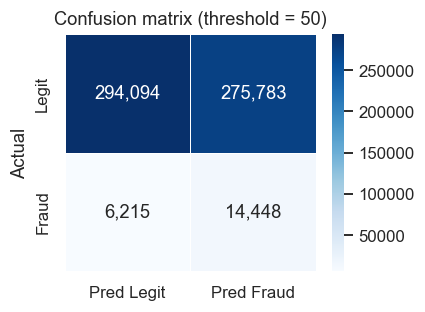

In [3]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True  Negatives (correct legit)  : {tn:>7,}")
print(f"False Positives (false alarms)   : {fp:>7,}")
print(f"False Negatives (missed fraud)   : {fn:>7,}")
print(f"True  Positives (caught fraud)   : {tp:>7,}")

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    pd.DataFrame(cm, index=['Legit','Fraud'], columns=['Pred Legit','Pred Fraud']),
    annot=True, fmt=',d', cmap='Blues', ax=ax, linewidths=0.5
)
ax.set_title('Confusion matrix (threshold = 50)')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 3. Precision–Recall tradeoff at different thresholds

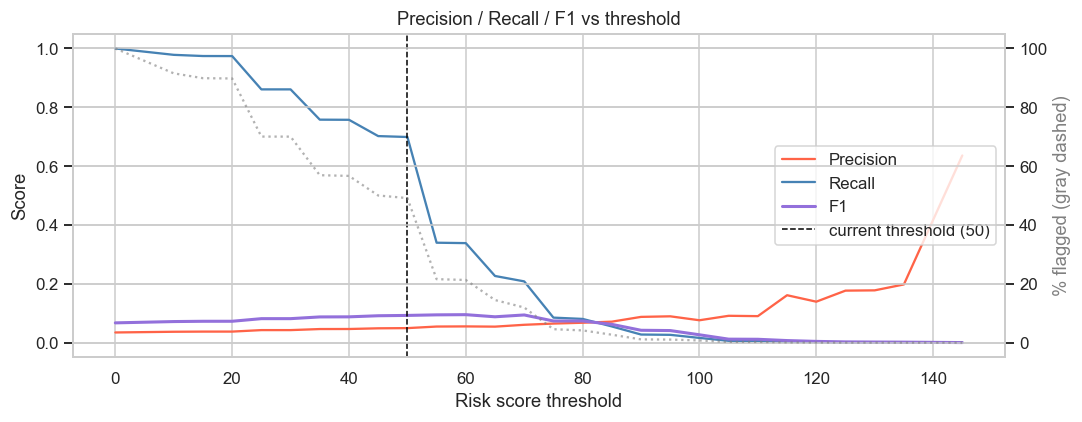

Best F1 threshold: 60  F1=0.095  P=0.056  R=0.339  flags 21.3% of orders
Current threshold: 50  F1=0.093


In [4]:
thresholds = sorted(df['risk_score'].unique())
rows = []
for t in thresholds:
    pred = (df['risk_score'] >= t).astype(int)
    tp_ = ((pred == 1) & (y_true == 1)).sum()
    fp_ = ((pred == 1) & (y_true == 0)).sum()
    fn_ = ((pred == 0) & (y_true == 1)).sum()
    prec = tp_ / (tp_ + fp_) if (tp_ + fp_) > 0 else 0
    rec  = tp_ / (tp_ + fn_) if (tp_ + fn_) > 0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec) > 0 else 0
    rows.append({'threshold': t, 'precision': prec, 'recall': rec, 'f1': f1,
                 'flagged_%': pred.mean()*100})

thresh_df = pd.DataFrame(rows)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='tomato')
ax1.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='steelblue')
ax1.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='mediumpurple', linewidth=2)
ax1.axvline(50, color='black', linestyle='--', linewidth=1, label='current threshold (50)')
ax1.set_xlabel('Risk score threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1 vs threshold')
ax1.legend(loc='center right')

ax2 = ax1.twinx()
ax2.plot(thresh_df['threshold'], thresh_df['flagged_%'], color='gray', linestyle=':', alpha=0.6)
ax2.set_ylabel('% flagged (gray dashed)', color='gray')

plt.tight_layout()
plt.show()

best = thresh_df.loc[thresh_df['f1'].idxmax()]
print(f"Best F1 threshold: {best['threshold']:.0f}  "
      f"F1={best['f1']:.3f}  P={best['precision']:.3f}  R={best['recall']:.3f}  "
      f"flags {best['flagged_%']:.1f}% of orders")
print(f"Current threshold: 50  "
      f"F1={thresh_df.loc[thresh_df.threshold==50,'f1'].values[0]:.3f}")

## 4. ROC curve

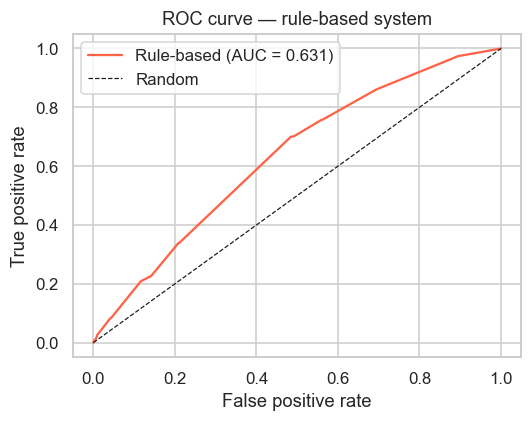

ROC-AUC : 0.6313


In [5]:
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color='tomato', label=f'Rule-based (AUC = {auc:.3f})')
ax.plot([0,1], [0,1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve — rule-based system')
ax.legend()
plt.tight_layout()
plt.show()

print(f"ROC-AUC : {auc:.4f}")

## 5. Precision-Recall curve

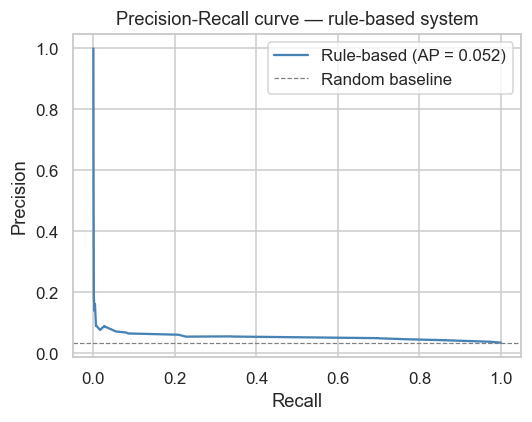

Average Precision: 0.0519


In [6]:
prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rec_c, prec_c, color='steelblue', label=f'Rule-based (AP = {ap:.3f})')
ax.axhline(y_true.mean(), color='gray', linestyle='--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall curve — rule-based system')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Average Precision: {ap:.4f}")

## 6. Baseline summary

| Metric | Value |
|--------|-------|
| Fraud rate | 3.50% |
| Threshold | 50 |
| ROC-AUC | *(run cell 4)* |
| Avg Precision | *(run cell 5)* |
| Fraud F1 | *(run cell 1)* |
| Fraud Precision | *(run cell 1)* |
| Fraud Recall | *(run cell 1)* |

**Target for ML models (notebook 04):** ROC-AUC > 0.90, Fraud F1 > 0.50